<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning - 2301CS621</b></center>

<center><b><h1>Lab - 4</b></center>    
<pre>    

## Simple Linear Regression

## Step 1. Import the necessary libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2. Import the dataset

In [6]:
df = pd.read_csv("50_Startups.csv")
df

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


## Step 3 . Check the State Column

In [8]:
df['State'].value_counts()

State
New York      17
California    17
Florida       16
Name: count, dtype: int64

## Step 4 . Splitting dataset in to input and output

In [10]:
x = df.iloc[::, :4:] 
y = df.iloc[::, 4]

print(x.head())
print(y.head())

   R&D Spend  Administration  Marketing Spend       State
0  165349.20       136897.80        471784.10    New York
1  162597.70       151377.59        443898.53  California
2  153441.51       101145.55        407934.54     Florida
3  144372.41       118671.85        383199.62    New York
4  142107.34        91391.77        366168.42     Florida
0    192261.83
1    191792.06
2    191050.39
3    182901.99
4    166187.94
Name: Profit, dtype: float64


## Step 5 . Convert state Column into Numeric Column

## Step 5.1 .  Perform Transformation

In [13]:
x = pd.get_dummies(x, columns=['State'] ,drop_first = True)
x

,R&D Spend,Administration,Marketing Spend,State_Florida,State_New York
0,165349.20,136897.80,471784.10,False,True
1,162597.70,151377.59,443898.53,False,False
2,153441.51,101145.55,407934.54,True,False
3,144372.41,118671.85,383199.62,False,True
4,142107.34,91391.77,366168.42,True,False
5,131876.90,99814.71,362861.36,False,True
6,134615.46,147198.87,127716.82,False,False
7,130298.13,145530.06,323876.68,True,False
8,120542.52,148718.95,311613.29,False,True
9,123334.88,108679.17,304981.62,False,False


## Step 6 . Dummy variable trap

In [56]:
# Already Performed using | drop_first =True


## Step 7 Splitting dataset in to Train and Test

In [65]:
from sklearn.model_selection import train_test_split
X = df.drop('Profit', axis=1)   
y = df['Profit']
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,     
    train_size=0.8,    
    random_state=42
)
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (40, 5)
X_test : (10, 5)
y_train: (40,)
y_test : (10,)


## Step 8  Import LinearRegression model from linear_model family 

In [72]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()     


## Step 9  Fit the data

In [74]:
model.fit(X_train, y_train)

LinearRegression()

## Step 10  Predict the data

In [94]:
y_predict = model.predict(X_test)
y_predict

array([126362.87908255,  84608.45383634,  99677.49425147,  46357.46068582,
       128750.48288504,  50912.4174188 , 109741.35032702, 100643.24281647,
        97599.27574594, 113097.42524432])

## Step 11  Display Result

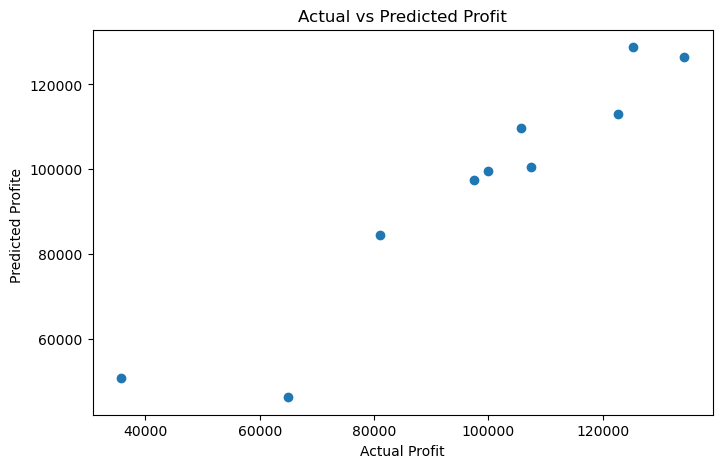

In [96]:
# y_test and y_predict
import matplotlib.pyplot as plt 
plt.figure(figsize=(8,5))
plt.scatter(y_test,y_predict)
plt.xlabel("Actual Profit")
plt.ylabel("Predicted Profite ")
plt.title("Actual vs Predicted Profit")
plt.show()

## RSS

In [90]:
rss = np.sum((y_test - y_predict) ** 2)
print("RSS:", rss)


RSS: 820103630.443011


## R Square

In [92]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print("R Square:", r2)


R Square: 0.8987266414328636
